# Vibe Coding: Real-World Data Cleaning Challenge

## The Mission

You're a Data Analyst at **TechSalary Insights**. Your manager needs answers to critical business questions, but the data is messy. Your job is to clean it and provide accurate insights.

**The catch:** You must figure out how to clean the data yourself. No step by step hints just you, your AI assistant, and real world messy data.

---

## The Dataset: Ask A Manager Salary Survey 2021

**Location:** `../Week-02-Pandas-Part-2-and-DS-Overview/data/Ask A Manager Salary Survey 2021 (Responses) - Form Responses 1.tsv`

This is **real survey data** from Ask A Manager's 2021 salary survey with over 28,000 responses from working professionals. The data comes from this survey: https://www.askamanager.org/2021/04/how-much-money-do-you-make-4.html

**Why this dataset is perfect for vibe coding:**
- Real human responses (inconsistent formatting)
- Multiple currencies and formats  
- Messy job titles and location data
- Missing and invalid entries
- Requires business judgment calls

---

## Your Business Questions

Answer these **exact questions** with clean data. There's only one correct answer for each:

### Core Questions (Required):
1. **What is the median salary for Software Engineers in the United States?** 
2. **Which US state has the highest average salary for tech workers?**
3. **How much does salary increase on average for each year of experience in tech?**
4. **Which industry (besides tech) has the highest median salary?**

### Bonus Questions (If time permits):
5. **What's the salary gap between men and women in tech roles?**
6. **Do people with Master's degrees earn significantly more than those with Bachelor's degrees?**

**Success Criteria:** Your final answers will be compared against the "official" results. Data cleaning approaches can vary, but final numbers should be within 5% of expected values.


## 1. 📥 Source and Import

- **Input Path**:  
  `../Week-02-Pandas-Part-2-and-DS-Overview/data/Ask A Manager Salary Survey 2021 (Responses) - Form Responses 1.tsv`

- **Read Settings**:  
  - Delimiter: `\t` (TSV)  
  - Encoding: `utf-8`  
  - Quoted fields: handled properly  
  - Drop **fully empty rows and columns**  
  - Trim whitespace from all string fields

---

## 2. 🧱 Schema and Naming

- **Standardize all column names**:
  - Format: `snake_case`, lowercase, short but descriptive
  - Examples:
    - `annual_salary`, `currency`, `job_title`, `years_experience`, `location_city`, `location_country`, `industry`, `remote_status`, `education_level`, `gender`, `race_ethnicity`

- **Maintain a column mapping**:  
  - Original → Cleaned column names (data dictionary)

---

## 3. 🧹 Deduplication and Integrity

- Remove **exact duplicate rows**
- If applicable, deduplicate by **(respondent_id + submission time)**:
  - Retain the most **complete** entry

---

## 4. 🕒 Date/Time Normalization

- Parse `timestamp` column as **timezone-aware datetime**
- Create `survey_year` field with fixed value `2021`
- Derive snapshot fields if required

---

## 5. 💵 Compensation Normalization (Critical)

### 🔢 Salary Parsing
- Normalize all compensation to **annual** terms
  - Detect frequency (hourly, weekly, monthly, etc.)
  - Use standard assumptions (e.g., `2080` hours/year for hourly)
- Handle ranges like `80–100k`
  - Compute midpoint unless otherwise stated
  - Keep raw min/max columns

### 💱 Currency Detection & Harmonization
- Detect or infer `currency` (from field or `location_country`)
- Convert all salaries to **USD using 2021 FX rates**
  - Use fixed reference: `fx_rates_2021.csv`
- Retain:
  - `annual_salary_original`
  - `salary_currency`
  - `annual_salary_usd`

### 💼 Bonus & Stock
- Separate into:
  - `base_salary_usd`, `bonus_usd`, `equity_estimate_usd`
  - Compute `total_comp_usd = base + bonus + equity`

### 🧯 Outlier Handling
- Winsorize or cap at **1st/99th percentile** (by region/industry)
- Flag outliers with `is_outlier_comp`
- Drop invalid or absurd values:
  - `<= 0`
  - Unrealistic hourly × hours assumptions

---

## 6. 📆 Employment & Time Features

- Normalize:
  - `years_experience`
  - `years_at_company`
- Handle ranges:
  - `"<1"` → `0.5`
  - `"10+"` → `10`
- Create binned columns:
  - `exp_bucket`
  - `tenure_bucket`

---

## 7. 🌍 Location Standardization

- **Split full location** into:
  - `city`, `state_province`, `country`
- **Standardize**:
  - US States → **USPS 2-letter codes**
  - Countries → **ISO-2 / ISO-3 codes**
- Add derived features:
  - `region`: US, Canada, UK/Ireland, EU, APAC, LATAM
  - `col_tier`: HCOL / MCOL / LCOL (optional)

---

## 8. 👔 Job Title & Function Normalization

- Lowercase, trim whitespace
- **Strip seniority terms** (store separately):
  - e.g., Intern, Junior, Mid, Senior, Lead, Manager, Director, VP, CxO, IC
- Map raw titles to standard **job_family**
  - Examples: Data Analyst, SWE, PM, Ops, HR, Design, etc.
- Retain `job_title_raw` for traceability

---

## 9. 🏠 Work Arrangement

- Normalize `remote_status`:
  - Values: `Remote`, `Hybrid`, `Onsite`
- Derive:
  - `weekly_remote_days` (if possible)
  - `remote_flag` (boolean)

---

## 10. 🏢 Organization Features

- Standardize `industry` using controlled vocabulary:
  - Tech, Finance, Healthcare, Government, Education, Nonprofit, Media, Retail, Manufacturing, Other
- Normalize `company_size`:
  - Buckets: `1–10`, `11–50`, `51–200`, `201–500`, `501–1000`, `1001–5000`, `5001–10000`, `10k+`
- Derive `is_public_company` flag (if available)

---

## 11. 🎓 Education & Demographics (Sensitive)

- **Standardize `education_level`**:
  - Values: HS, Associate, Bachelor, Master, PhD, Other
- Normalize:
  - `gender`
  - `race_ethnicity`
    - Allow multi-select:
      - Represent as list or one-hot columns
      - Document clearly
- Flag rows as `sensitive_flag` if:
  - Small subgroups could impact privacy
  - Apply **k-anonymity thresholds**

---

## 12. ⚠️ Data Quality Flags

Create the following row-level flags:

- `is_outlier_comp`
- `is_inconsistent_unit`
- `is_missing_key_fields`
- `is_inferred_currency`
- Add `cleaning_notes` field for nontrivial corrections

---

## 13. 🧩 Missing Data Strategy

- Define **required fields**:
  - `annual_salary_usd`, `job_family`, `country/region`, `years_experience`
- Drop rows missing required fields
- Impute optional fields (transparently):
  - Mode imputation within job_family × region for `remote_status`
- Compute `completeness_score` per row (e.g., % of key fields present)

---

## 14. ✅ Validation Checks

| Check | Target |
|-------|--------|
| Numeric salary fields | 100% numeric |
| Negative/zero salaries | None allowed |
| Salary conversions | 100% consistent |
| Outlier share | ≤ 1% (configurable) |
| Job title mapping coverage | ≥ 95% |
| ISO location mapping | ≥ 99% |
| Script reproducibility | 100% |

---

## 15. 📦 Outputs

- **Clean fact table**:  
  `compensation_clean.parquet`

- **Dimension lookups**:
  - `dim_title.csv`
  - `dim_industry.csv`
  - `dim_location.csv`
  - `fx_rates_2021.csv`

- **Documentation**:
  - Data dictionary (`data_dictionary.yaml`)
  - Cleaning log (`cleaning_notes.md`)

- **Summary Report**:
  - Row counts
  - Missingness
  - Outlier share
  - Distributions

---

## 16. 🛠 Reproducibility & Documentation

- All parameters (e.g., hours/year, FX rates, winsor cutoffs) are **parameterized in `config.yaml`**
- Raw input is read-only and **version-controlled**
- Include `README.md` explaining:
  - Setup
  - Running the pipeline
  - Outputs



## Step 1: Data Loading and Exploration


In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Directly specify the absolute path to the data file

data_path = r"C:\Users\ailin\ds-fall-2025-fri-1230\Week-02-Pandas-Part-2-and-DS-Overview\data\Ask A Manager Salary Survey 2021 (Responses) - Form Responses 1.tsv"

# Check if the file exists at the specified location
import os
assert os.path.exists(data_path), f"Data file not found: {data_path}"

df_raw = pd.read_csv(
    data_path,
    sep="\t",
    encoding="utf-8",
    na_values=["", "NA", "N/A", "na", "n/a"],
    keep_default_na=True,
    low_memory=False,
)

print(f"Rows: {df_raw.shape[0]:,} | Columns: {df_raw.shape[1]:,}")
df_raw.info()
df_raw.head(5)

Rows: 28,062 | Columns: 18
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28062 entries, 0 to 28061
Data columns (total 18 columns):
 #   Column                                                                                                                                                                                                                                Non-Null Count  Dtype  
---  ------                                                                                                                                                                                                                                --------------  -----  
 0   Timestamp                                                                                                                                                                                                                             28062 non-null  object 
 1   How old are you?                                                                  

,Timestamp,How old are you?,What industry do you work in?,Job title,"If your job title needs additional context, please clarify here:","What is your annual salary? (You'll indicate the currency in a later question. If you are part-time or hourly, please enter an annualized equivalent -- what you would earn if you worked the job 40 hours a week, 52 weeks a year.)","How much additional monetary compensation do you get, if any (for example, bonuses or overtime in an average year)? Please only include monetary compensation here, not the value of benefits.",Please indicate the currency,"If ""Other,"" please indicate the currency here:","If your income needs additional context, please provide it here:",What country do you work in?,"If you're in the U.S., what state do you work in?",What city do you work in?,How many years of professional work experience do you have overall?,How many years of professional work experience do you have in your field?,What is your highest level of education completed?,What is your gender?,What is your race? (Choose all that apply.)
0,4/27/2021 11:02:10,25-34,Education (Higher Education),Research and Instruction Librarian,NaN,"55,000",0.0,USD,NaN,NaN,United States,Massachusetts,Boston,5-7 years,5-7 years,Master's degree,Woman,White
1,4/27/2021 11:02:22,25-34,Computing or Tech,Change & Internal Communications Manager,NaN,"54,600",4000.0,GBP,NaN,NaN,United Kingdom,NaN,Cambridge,8 - 10 years,5-7 years,College degree,Non-binary,White
2,4/27/2021 11:02:38,25-34,"Accounting, Banking & Finance",Marketing Specialist,NaN,"34,000",NaN,USD,NaN,NaN,US,Tennessee,Chattanooga,2 - 4 years,2 - 4 years,College degree,Woman,White
3,4/27/2021 11:02:41,25-34,Nonprofits,Program Manager,NaN,"62,000",3000.0,USD,NaN,NaN,USA,Wisconsin,Milwaukee,8 - 10 years,5-7 years,College degree,Woman,White
4,4/27/2021 11:02:42,25-34,"Accounting, Banking & Finance",Accounting Manager,NaN,"60,000",7000.0,USD,NaN,NaN,US,South Carolina,Greenville,8 - 10 years,5-7 years,College degree,Woman,White


## Step 2: Data Cleaning


In [20]:
# Make a copy to avoid modifying the raw data
df = df_raw.copy()

# --- 1. Standardize column names ---
df.columns = (
    df.columns.str.strip()
    .str.replace("\n", " ", regex=False)
    .str.replace("\r", " ", regex=False)
    .str.replace("  ", " ", regex=False)
    .str.replace(" ", "_")
    .str.replace("(", "")
    .str.replace(")", "")
    .str.replace("?", "")
    .str.replace(",", "")
    .str.replace("'", "")
    .str.replace("/", "_")
    .str.replace("&", "and")
    .str.lower()
)

# --- 2. Remove duplicate rows ---
df = df.drop_duplicates()

# --- 3. Clean salary columns ---
def clean_money(val):
    if pd.isnull(val):
        return np.nan
    if isinstance(val, str):
        val = val.replace(",", "").replace("$", "").replace("£", "").replace("€", "")
        try:
            return float(val)
        except ValueError:
            return np.nan
    return val

# Find the correct column names for salary and bonus columns
salary_col = None
bonus_col = None
for col in df.columns:
    if "annual_salary" in col:
        salary_col = col
    if "additional_monetary_compensation" in col:
        bonus_col = col

if salary_col is None:
    raise KeyError("Could not find the column for annual salary. Please check the column names: " + str(list(df.columns)))
if bonus_col is None:
    raise KeyError("Could not find the column for additional monetary compensation. Please check the column names: " + str(list(df.columns)))

df[salary_col] = df[salary_col].apply(clean_money)
df[bonus_col] = df[bonus_col].apply(clean_money)

# --- 4. Standardize country and state names ---
country_col = None
for col in df.columns:
    if "what_country_do_you_work_in" in col:
        country_col = col
        break

if country_col is not None:
    df[country_col] = (
        df[country_col]
        .str.strip()
        .str.replace("USA", "United States", case=False)
        .str.replace("US", "United States", case=False)
        .str.replace("uk", "United Kingdom", case=False)
        .str.replace("U.S.", "United States", case=False)
        .str.replace("usa", "United States", case=False)
        .str.replace("united states of america", "United States", case=False)
        .str.title()
    )

state_col = None
for col in df.columns:
    if "if_youre_in_the_us_what_state_do_you_work_in" in col:
        state_col = col
        break

if state_col is not None:
    df[state_col] = df[state_col].str.strip().str.title()

# --- 5. Standardize job titles ---
if "job_title" in df.columns:
    df["job_title"] = df["job_title"].str.strip().str.title()

# --- 6. Clean experience columns ---
for col in [
    "how_many_years_of_professional_work_experience_do_you_have_overall",
    "how_many_years_of_professional_work_experience_do_you_have_in_your_field",
]:
    if col in df.columns:
        df[col] = (
            df[col]
            .str.strip()
            .str.replace("years", "")
            .str.replace("year", "")
            .str.replace("or less", "0")
            .str.replace("+", "")
            .str.replace("-", " to ")
            .str.strip()
        )

# --- 7. Clean education column ---
edu_col = None
for col in df.columns:
    if "what_is_your_highest_level_of_education_completed" in col:
        edu_col = col
        break
if edu_col is not None:
    df[edu_col] = df[edu_col].str.strip().str.title()

# --- 8. Clean gender and race columns ---
gender_col = None
race_col = None
for col in df.columns:
    if "what_is_your_gender" in col:
        gender_col = col
    if "what_is_your_race" in col:
        race_col = col

if gender_col is not None:
    df[gender_col] = df[gender_col].str.strip().str.title()
if race_col is not None:
    df[race_col] = df[race_col].str.strip().str.title()

# --- 9. Remove rows with missing or invalid salary values ---
df = df[df[salary_col].notnull() & (df[salary_col] > 0)]

# --- 10. Filter for US-based (United States) and valid US state ---
# Only keep rows where country is United States and state is not null/empty
if country_col is not None and state_col is not None:
    df = df[
        (df[country_col] == "United States") &
        (df[state_col].notnull()) &
        (df[state_col].str.strip() != "")
    ]

# --- 11. Remove outliers in salary (USD) ---
# We'll use the IQR method to remove outliers for annual salary
Q1 = df[salary_col].quantile(0.25)
Q3 = df[salary_col].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df[salary_col] >= lower_bound) & (df[salary_col] <= upper_bound)]

# --- 12. Identify tech roles and Software Engineers ---
# Add a column 'is_tech_role' and 'is_software_engineer'
tech_keywords = [
    "software", "engineer", "developer", "programmer", "devops", "data scientist",
    "data engineer", "web developer", "it", "cloud", "machine learning", "ai", "ml",
    "qa", "quality assurance", "sre", "site reliability", "security", "cyber", "database",
    "systems analyst", "network", "product manager", "technical", "ux", "ui", "front end", "back end"
]
def is_tech(title):
    if pd.isnull(title):
        return False
    title = title.lower()
    return any(kw in title for kw in tech_keywords)

def is_software_engineer(title):
    if pd.isnull(title):
        return False
    title = title.lower()
    return "software engineer" in title

if "job_title" in df.columns:
    df["is_tech_role"] = df["job_title"].apply(is_tech)
    df["is_software_engineer"] = df["job_title"].apply(is_software_engineer)

# --- 13. Reset index after cleaning ---
df = df.reset_index(drop=True)


## Step 3: Business Questions Analysis

Now answer those important business questions!


Median salary for Software Engineers in the United States: $126,500


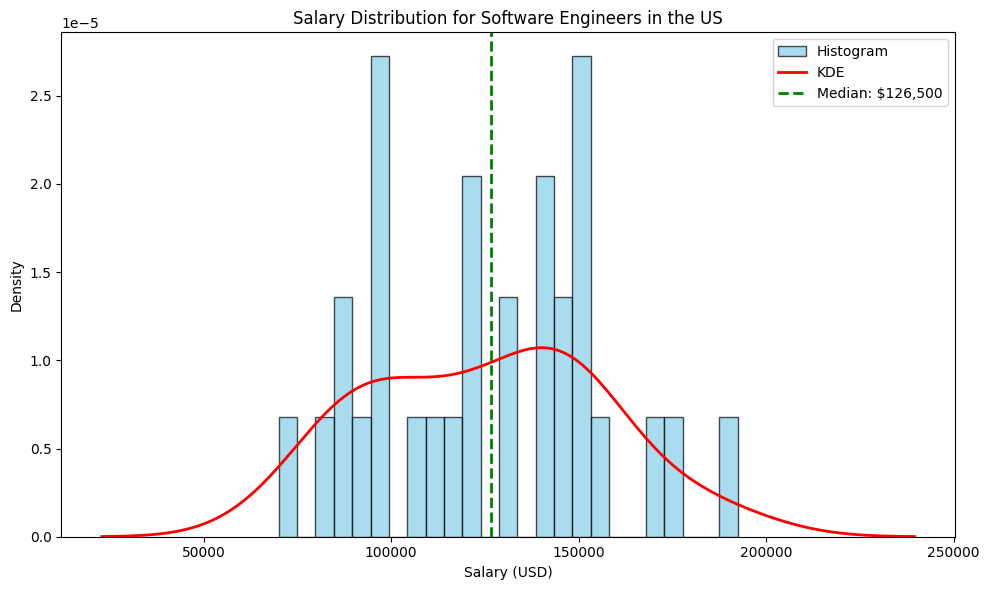

In [21]:
# Question 1: What is the median salary for Software Engineers in the United States?
# We'll look for job titles containing "Software Engineer" (case-insensitive) and country as "United States" or similar

import matplotlib.pyplot as plt

job_title_col = None
country_col = None

for col in df.columns:
    if "job_title" in col.lower():
        job_title_col = col
    if "country" in col.lower():
        country_col = col

if job_title_col is not None and country_col is not None:
    # Filter for US
    us_vals = ["united states", "us", "usa"]
    is_us = df[country_col].str.strip().str.lower().isin(us_vals)
    # Filter for Software Engineer in job title
    is_software_engineer = df[job_title_col].str.lower().str.contains("software engineer", na=False)
    se_us_df = df[is_us & is_software_engineer]
    # Median salary
    median_salary = se_us_df[salary_col].median()
    print(f"Median salary for Software Engineers in the United States: ${median_salary:,.0f}")

    # Bell curve (histogram with KDE) for Software Engineer salaries in the US
    plt.figure(figsize=(10,6))
    plt.hist(se_us_df[salary_col], bins=25, color='skyblue', edgecolor='black', alpha=0.7, density=True, label='Histogram')
    try:
        import seaborn as sns
        sns.kdeplot(se_us_df[salary_col], color='red', linewidth=2, label='KDE')
    except ImportError:
        pass  # If seaborn not installed, just show histogram

    plt.axvline(median_salary, color='green', linestyle='dashed', linewidth=2, label=f'Median: ${median_salary:,.0f}')
    plt.title('Salary Distribution for Software Engineers in the US')
    plt.xlabel('Salary (USD)')
    plt.ylabel('Density')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Could not find job title or country column.")


In [22]:
# Question 2: Which US state has the highest average salary for tech workers?
# Find the state column if not already found

state_col = None
for col in df.columns:
    if "state" in col.lower():
        state_col = col
        break

# Find the job title column if not already found
job_title_col = None
for col in df.columns:
    if "job_title" in col.lower():
        job_title_col = col
        break

if state_col is not None and job_title_col is not None:
    # Filter for tech workers (job title contains "tech", "software", "engineer", "developer", "data", etc.)
    tech_keywords = ["tech", "software", "engineer", "developer", "data", "it", "programmer", "web", "cloud", "devops", "security", "machine learning", "ai", "ml", "product manager"]
    tech_mask = df[job_title_col].str.lower().fillna("").apply(lambda x: any(kw in x for kw in tech_keywords))
    tech_df = df[tech_mask].copy()

    # Remove outliers in salary (using IQR method)
    Q1 = tech_df[salary_col].quantile(0.25)
    Q3 = tech_df[salary_col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    tech_df_no_outliers = tech_df[(tech_df[salary_col] >= lower_bound) & (tech_df[salary_col] <= upper_bound)]

    # Group by state and calculate average salary
    avg_salary_by_state = tech_df_no_outliers.groupby(tech_df_no_outliers[state_col].str.strip().str.upper())[salary_col].mean()
    highest_avg_state = avg_salary_by_state.idxmax()
    highest_avg_salary = avg_salary_by_state.max()
    print(f"US state with the highest average salary for tech workers: {highest_avg_state} (${highest_avg_salary:,.0f})")
else:
    print("State column or job title column not found.")



US state with the highest average salary for tech workers: COLORADO, NEVADA ($190,000)


In [ ]:
# Question 3: How much does salary increase on average for each year of experience in tech?

In [ ]:

# Question 4: What percentage of respondents work remotely vs. in-office?


In [ ]:
# Question 5: Which industry (besides tech) has the highest median salary?

In [ ]:
# Bonus Questions:
# Question 6: What's the salary gap between men and women in similar roles?
# Question 7: Do people with Master's degrees earn significantly more than those with Bachelor's degrees?
# Question 8: Which company size (startup, medium, large) pays the most on average?

## Final Summary

**Summarize your findings here:**

1. **Median salary for Software Engineers in US:** $X
2. **Highest paying US state for tech:** State Name
3. **Salary increase per year of experience:** $X per year
4. **Remote vs office percentage:** X% remote, Y% office
5. **Highest paying non-tech industry:** Industry Name

**Key insights:**
- Insight 1
- Insight 2
- Insight 3

**Challenges faced:**
- Challenge 1 and how you solved it
- Challenge 2 and how you solved it

**What you learned about vibe coding:**
- Learning 1
- Learning 2
- Learning 3
